In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import kstest, chi2

# Exercise 3

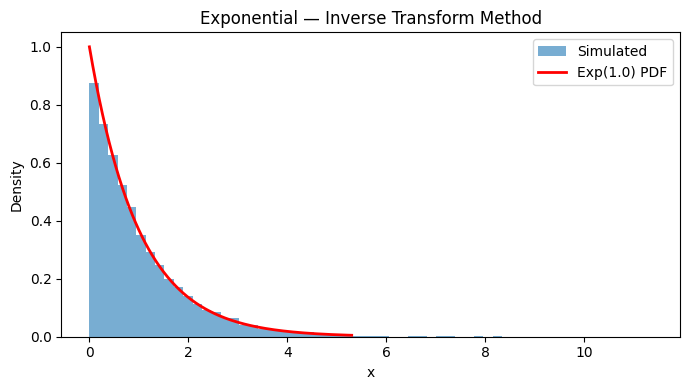

-- KS test ---------------------------------------------
  statistic : 0.01253   p = 0.0859   Reject H0: False

-- Chi^2 test (50 equal-prob bins, df=49) ----------------
  statistic : 50.4900   critical : 66.3386   p = 0.4144   Reject H0: False

  Sample: mean=1.0141  std=1.0057   (theoretical: mean=1.0000  std=1.0000)


In [38]:
# Exponential Distribution

def sample_exponential(lam, n):
    U = np.random.uniform(size=n)
    return -np.log(U) / lam

N, lam = 10_000, 1.0
np.random.seed(42)
exp_samples = sample_exponential(lam, N)

dist_exp = stats.expon(scale=1 / lam)

x = np.linspace(0, dist_exp.ppf(0.995), 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(exp_samples, bins=60, density=True, alpha=0.6, label="Simulated")
ax.plot(x, dist_exp.pdf(x), "r-", lw=2, label=f"Exp({lam}) PDF")
ax.set_xlabel("x"); ax.set_ylabel("Density")
ax.set_title("Exponential — Inverse Transform Method")
ax.legend(); plt.tight_layout(); plt.show()

ks_stat, ks_p = kstest(exp_samples, dist_exp.cdf)
print("-- KS test ---------------------------------------------")
print(f"  statistic : {ks_stat:.5f}   p = {ks_p:.4f}   Reject H0: {ks_p < 0.05}")

B = 50
edges = dist_exp.ppf(np.linspace(0, 1, B + 1))
edges[-1] = np.inf
obs = np.histogram(exp_samples, bins=edges)[0]
chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)
crit = chi2.ppf(0.95, df=B - 1)
print(f"\n-- Chi^2 test ({B} equal-prob bins, df={B-1}) ----------------")
print(f"  statistic : {chi_stat:.4f}   critical : {crit:.4f}   p = {chi_p:.4f}   Reject H0: {chi_p < 0.05}")

print(f"\n  Sample: mean={exp_samples.mean():.4f}  std={exp_samples.std():.4f}   "
      f"(theoretical: mean={1/lam:.4f}  std={1/lam:.4f})")

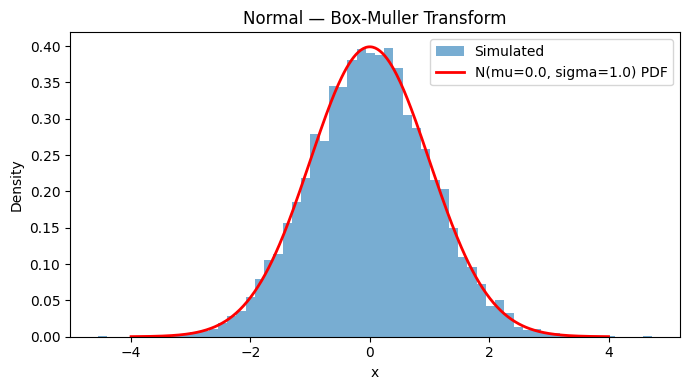

--------------
KS test:
-----
statistic : 0.00560   
p = 0.9109   
Reject H0: False

---------------
Chi^2 test (50 equal-prob bins, df=49): 
-----
statistic : 58.3900   
critical : 66.3386   
p = 0.1684   
Reject H0: False

Sample: mean=0.0059  std=1.0063   (theoretical: mean=0.0000  std=1.0000)


In [39]:
# Normal Distribution

def box_muller(mu, sigma, n):
    m = (n + 1) // 2
    U1 = np.random.uniform(size=m)
    U2 = np.random.uniform(size=m)
    R = np.sqrt(-2 * np.log(U1))
    Z = np.concatenate([R * np.cos(2 * np.pi * U2),
                        R * np.sin(2 * np.pi * U2)])[:n]
    return mu + sigma * Z

N, mu, sigma = 10_000, 0.0, 1.0
np.random.seed(42)
norm_samples = box_muller(mu, sigma, N)

dist_norm = stats.norm(loc=mu, scale=sigma)

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(norm_samples, bins=60, density=True, alpha=0.6, label="Simulated")
ax.plot(x, dist_norm.pdf(x), "r-", lw=2, label=f"N(mu={mu}, sigma={sigma}) PDF")
ax.set_xlabel("x"); ax.set_ylabel("Density")
ax.set_title("Normal — Box-Muller Transform")
ax.legend(); plt.tight_layout(); plt.show()

ks_stat, ks_p = kstest(norm_samples, dist_norm.cdf)
print("--------------\nKS test:\n-----")
print(f"statistic : {ks_stat:.5f}   \np = {ks_p:.4f}   \nReject H0: {ks_p < 0.05}")

B = 50
edges = dist_norm.ppf(np.linspace(0, 1, B + 1))
edges[0], edges[-1] = -np.inf, np.inf
obs = np.histogram(norm_samples, bins=edges)[0]
chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)
crit = chi2.ppf(0.95, df=B - 1)
print(f"\n---------------\nChi^2 test ({B} equal-prob bins, df={B-1}): \n-----")
print(f"statistic : {chi_stat:.4f}   \ncritical : {crit:.4f}   \np = {chi_p:.4f}   \nReject H0: {chi_p < 0.05}")

print(f"\nSample: mean={norm_samples.mean():.4f}  std={norm_samples.std():.4f}   "
      f"(theoretical: mean={mu:.4f}  std={sigma:.4f})")

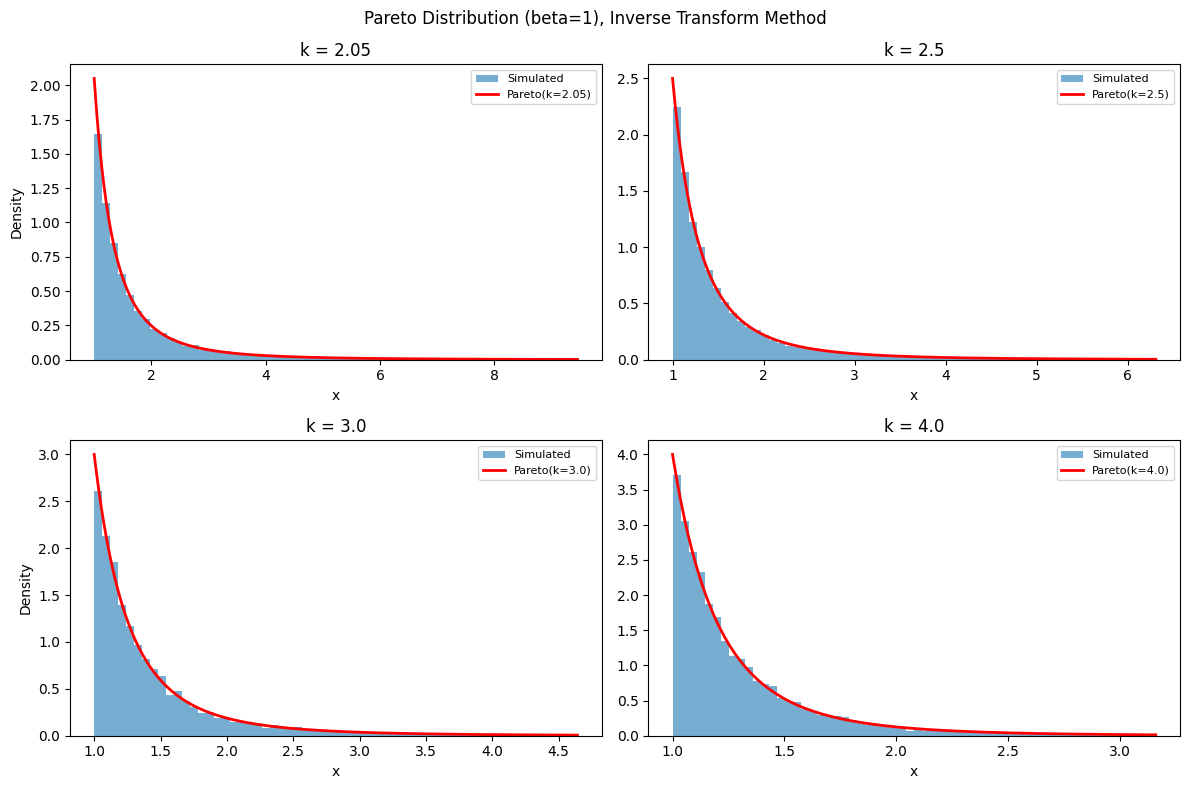


     k     KS stat      KS p  Chi^2 stat   Chi^2 p    Mean(th)     Var(th)
──────────────────────────────────────────────────────────────────────────
  2.05     0.01253    0.0859     50.4900    0.4144      1.9524     37.1882
   2.5     0.00965    0.3072     33.8700    0.9508      1.6667      2.2222
   3.0     0.00729    0.6606     47.3500    0.5402      1.5000      0.7500
   4.0     0.00608    0.8514     32.6700    0.9649      1.3333      0.2222


In [40]:
# Pareto Distribution
np.random.seed(42)

def sample_pareto(beta, k, n):
    U = np.random.uniform(size=n)
    return beta * U ** (-1.0 / k)

beta = 1.0
k_values = [2.05, 2.5, 3.0, 4.0]
N = 10_000
B = 50

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

summary = []
for col, k in enumerate(k_values):
    ax = axes[col // 2, col % 2]
    samples = sample_pareto(beta, k, N)
    dist_par = stats.pareto(b=k, scale=beta)

    x_max = dist_par.ppf(0.99)
    x = np.linspace(beta, x_max, 400)

    ax.hist(samples[samples <= x_max], bins=60, density=True,
            alpha=0.6, label="Simulated")
    ax.plot(x, dist_par.pdf(x), "r-", lw=2, label=f"Pareto(k={k})")
    ax.set_title(f"k = {k}"); ax.set_xlabel("x")
    if col % 2 == 0:
        ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    # KS test
    ks_stat, ks_p = kstest(samples, dist_par.cdf)

    # Chi-squared with equal-probability bins
    edges = dist_par.ppf(np.linspace(0, 1, B + 1))
    edges[-1] = np.inf
    obs = np.histogram(samples, bins=edges)[0]
    chi_stat = ((obs - N / B) ** 2 / (N / B)).sum()
    chi_p = 1 - chi2.cdf(chi_stat, df=B - 1)

    mean_th = k * beta / (k - 1)
    var_th = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")
    var_str = "∞" if np.isinf(var_th) else f"{var_th:.4f}"

    summary.append((k, ks_stat, ks_p, chi_stat, chi_p, mean_th, var_str))

plt.suptitle("Pareto Distribution (beta=1), Inverse Transform Method")
plt.tight_layout()
plt.show()

# Summary table
print(f"\n{'k':>6}  {'KS stat':>10}  {'KS p':>8}  {'Chi^2 stat':>10}  {'Chi^2 p':>8}  "
      f"{'Mean(th)':>10}  {'Var(th)':>10}")
print("─" * 74)
for k, ks_s, ks_p, chi_s, chi_p, mean_th, var_str in summary:
    print(f"{k:>6}  {ks_s:>10.5f}  {ks_p:>8.4f}  {chi_s:>10.4f}  {chi_p:>8.4f}  "
          f"{mean_th:>10.4f}  {var_str:>10}")

     k     E[X] (th)    E[X] (samp)     Var(X) (th)   Var(X) (samp)
──────────────────────────────────────────────────────────────────
  2.05        1.9524         1.9999         37.1882         15.4829
   2.5        1.6667         1.6881          2.2222          3.0522
   3.0        1.5000         1.5122          0.7500          0.9832
   4.0        1.3333         1.3397          0.2222          0.2586


C:\Users\Vikto\AppData\Local\Temp\ipykernel_25976\3056122271.py:28: RuntimeWarning: invalid value encountered in divide
  (cumsum2 / ns - run_mean ** 2) * ns / (ns - 1),


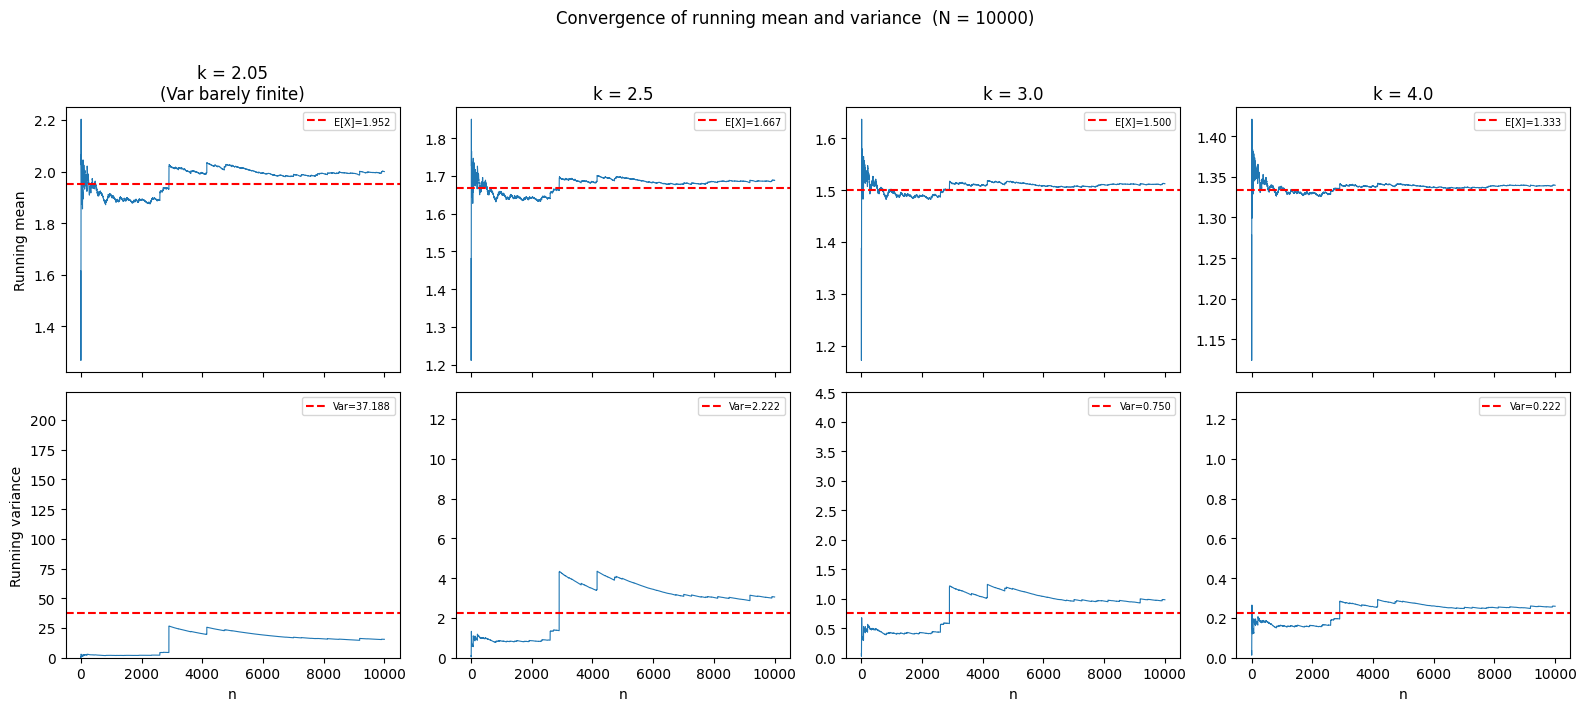

In [41]:
# Mean & Variance

print(f"{'k':>6}  {'E[X] (th)':>12}  {'E[X] (samp)':>13}  {'Var(X) (th)':>14}  {'Var(X) (samp)':>14}")
print("─" * 66)
for k in k_values:
    np.random.seed(42)
    s = sample_pareto(beta, k, N)
    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")
    var_str = f"{var_th:>14.4f}" if not np.isinf(var_th) else f"{'infty':>14}"
    print(f"{k:>6}  {mean_th:>12.4f}  {s.mean():>13.4f}  {var_str}  {s.var(ddof=1):>14.4f}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
ns = np.arange(1, N + 1)

titles = ["k = 2.05\n(Var barely finite)", "k = 2.5", "k = 3.0", "k = 4.0"]
for col, k in enumerate(k_values):
    np.random.seed(42)
    s = sample_pareto(beta, k, N)
    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k - 2) * (k - 1)**2) if k > 2 else float("inf")

    cumsum  = np.cumsum(s)
    cumsum2 = np.cumsum(s ** 2)
    run_mean = cumsum / ns
    # unbiased running variance via cumulative sums
    run_var = np.where(ns > 1,
                       (cumsum2 / ns - run_mean ** 2) * ns / (ns - 1),
                       np.nan)

    ax1 = axes[0, col]
    ax1.plot(ns, run_mean, lw=0.8)
    ax1.axhline(mean_th, color="r", lw=1.5, ls="--", label=f"E[X]={mean_th:.3f}")
    ax1.set_title(titles[col])
    ax1.legend(fontsize=7)
    if col == 0:
        ax1.set_ylabel("Running mean")

    ax2 = axes[1, col]
    ax2.plot(ns[1:], run_var[1:], lw=0.8)
    if not np.isinf(var_th):
        ax2.axhline(var_th, color="r", lw=1.5, ls="--", label=f"Var={var_th:.3f}")
        ax2.set_ylim(0, var_th * 6)
    ax2.legend(fontsize=7)
    ax2.set_xlabel("n")
    if col == 0:
        ax2.set_ylabel("Running variance")

plt.suptitle(f"Convergence of running mean and variance  (N = {N})", y=1.01)
plt.tight_layout()
plt.show()


In [42]:
# 95% Confidence Intervals for mean and variance (n=10, 100 replications)

n, M, alpha = 10, 100, 0.05
mu_true, sigma2_true = 0.0, 1.0

np.random.seed(42)
obs = np.random.normal(mu_true, np.sqrt(sigma2_true), size=(M, n))

xbar = obs.mean(axis=1)
s    = obs.std(axis=1, ddof=1)
s2   = s ** 2

# CI for mean
t_crit    = stats.t.ppf(1 - alpha / 2, df=n - 1)
ci_mu_lo  = xbar - t_crit * s / np.sqrt(n)
ci_mu_hi  = xbar + t_crit * s / np.sqrt(n)

# CI for variance
chi2_lo   = stats.chi2.ppf(alpha / 2,     df=n - 1)
chi2_hi   = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
ci_var_lo = (n - 1) * s2 / chi2_hi
ci_var_hi = (n - 1) * s2 / chi2_lo

cover_mu  = (ci_mu_lo  <= mu_true)     & (mu_true     <= ci_mu_hi)
cover_var = (ci_var_lo <= sigma2_true) & (sigma2_true <= ci_var_hi)

print(f"t critical value  : t(0.025, {n-1}) = {t_crit:.4f}")
print(f"Chi^2 critical values: Chi^2 (0.025, {n-1}) = {chi2_lo:.4f},  Chi^2 (0.975, {n-1}) = {chi2_hi:.4f}")
print(f"\nCI width mean    : mean = {(ci_mu_hi  - ci_mu_lo ).mean():.4f}  "
      f"std = {(ci_mu_hi  - ci_mu_lo ).std():.4f}")
print(f"CI width variance: mean = {(ci_var_hi - ci_var_lo).mean():.4f}  "
      f"std = {(ci_var_hi - ci_var_lo).std():.4f}")
print(f"\nCoverage  mean: {cover_mu.sum()}/100    variance: {cover_var.sum()}/100    (nominal: 95/100)")

t critical value  : t(0.025, 9) = 2.2622
Chi^2 critical values: Chi^2 (0.025, 9) = 2.7004,  Chi^2 (0.975, 9) = 19.0228

CI width mean    : mean = 1.3586  std = 0.3293
CI width variance: mean = 2.7302  std = 1.2831

Coverage  mean: 95/100    variance: 97/100    (nominal: 95/100)


In [43]:
def sample_pareto_composition(beta, k, n):
    np.random.seed(42)
    lam = np.random.gamma(shape=k, scale=1.0 / beta, size=n)
    X   = np.random.exponential(scale=1.0 / lam)
    return X + beta


     k     KS stat      KS p        Mean           Var
--------------------------------------------------------
  2.05     0.01364    0.0479      1.9165        6.8900
        (theoretical)                1.9524       37.1882

   2.5     0.01601    0.0118      1.6403        1.8073
        (theoretical)                1.6667        2.2222

   3.0     0.00986    0.2837      1.4866        0.7652
        (theoretical)                1.5000        0.7500

   4.0     0.01335    0.0562      1.3255        0.2295
        (theoretical)                1.3333        0.2222



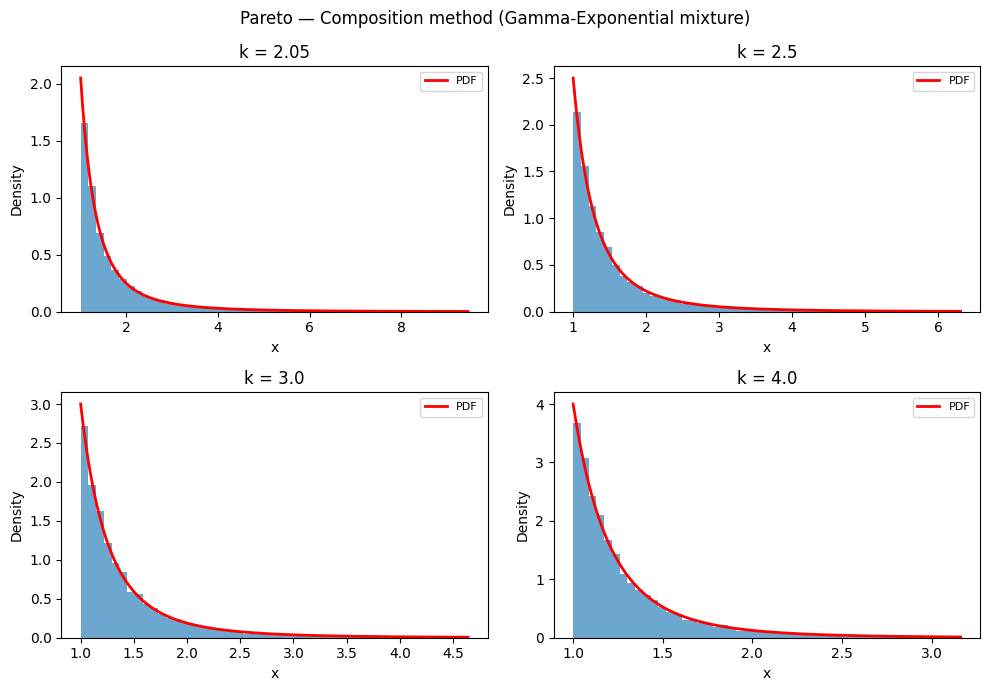

In [49]:
# Pareto via Composition
N = 10000
beta = 1.0
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

print(f"{'k':>6}  {'KS stat':>10}  {'KS p':>8}  {'Mean':>10}  {'Var':>12}")
print("-" * 56)

for col, k in enumerate(k_values):
    dist  = stats.pareto(b=k, scale=beta)
    x_max = dist.ppf(0.99)
    x_pdf = np.linspace(beta, x_max, 400)

    s = sample_pareto_composition(beta, k, N)

    ax = axes[col // 2, col % 2]
    ax.hist(s[s <= x_max], bins=50, density=True, alpha=0.65)
    ax.plot(x_pdf, dist.pdf(x_pdf), "r-", lw=2, label="PDF")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("x")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

    ks_s, ks_p = kstest(s, dist.cdf)
    mean_th = k * beta / (k - 1)
    var_th  = k * beta**2 / ((k-2)*(k-1)**2) if k > 2 else float("inf")
    print(f"{k:>6}  {ks_s:>10.5f}  {ks_p:>8.4f}  {s.mean():>10.4f}  {s.var(ddof=1):>12.4f}")
    print(f"{''  :>6}  {'(theoretical)':>10}  {''  :>8}  "
          f"{mean_th:>10.4f}  {var_th if not np.isinf(var_th) else chr(8734):>12.4f}")
    print()

plt.suptitle("Pareto — Composition method (Gamma-Exponential mixture)")
plt.tight_layout()
plt.show()
